In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.0 MB 6.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/10.0 MB 6.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/10.0 MB 5.8 MB/s eta 0:00:02
   ----------------- ---------------------- 4.5/10.0 MB 5.8 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/10.0 MB 5.9 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/10.0 MB 5.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/10.0 MB 6.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/10.0 MB 5.5 MB/s eta 0:00:01
   ------------------------------------- -- 9.4/10.0 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 3.4 MB/s eta 0:00:04
   ---- -------


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectFromModel

## Load dataset and basic checks

In [2]:
df = pd.read_csv(r"D:/sivabalam/itsm_ml/ISTM_ML/Data/tickets.csv")

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8992\3674793999.py:1: DtypeWarning: Columns (0: Urgency) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:/sivabalam/itsm_ml/ISTM_ML/Data/tickets.csv")


In [3]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='str')

In [14]:
df.isnull().sum()/len(df)

CI_Name                       0.000000
CI_Cat                        0.002382
CI_Subcat                     0.002382
WBS                           0.000000
Incident_ID                   0.000000
Status                        0.000000
Impact                        0.000000
Urgency                       0.000000
Priority                      0.029610
number_cnt                    0.000000
Category                      0.000000
KB_number                     0.000000
Alert_Status                  0.000000
No_of_Reassignments           0.000021
Open_Time                     0.000000
Reopen_Time                   0.950993
Resolved_Time                 0.038193
Close_Time                    0.000000
Handle_Time_hrs               0.000021
Closure_Code                  0.009870
No_of_Related_Interactions    0.002446
Related_Interaction           0.000000
No_of_Related_Incidents       0.973780
No_of_Related_Changes         0.987984
Related_Change                0.987984
dtype: float64

In [15]:
df.describe()

,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000


In [16]:
df.describe(include='object')

C:\Users\Welcome\AppData\Local\Temp\ipykernel_13024\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Category,KB_number,Alert_Status,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,Related_Interaction,Related_Change
count,46606,46495,46495,46606,46606,46606,46606,46606,46606,46606,46606,46606,2284,44826,46606,46605,46146,46606,560
unique,3019,12,64,274,46606,2,6,11,4,1825,1,34636,2244,33627,34528,30638,14,43060,232
top,SUB000456,application,Server Based Application,WBS000073,IM0000004,Closed,4,4,incident,KM0001106,closed,24-03-2014 08:54,15-10-2013 09:53,10-10-2013 12:53,02-10-2013 15:20,0,Other,#MULTIVALUE,C00003013
freq,3050,32900,18811,13342,1,46597,22556,15526,37748,1106,46606,7,2,7,21,236,16470,3434,110


In [17]:
df.isnull().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  str    
 1   CI_Cat                      46495 non-null  str    
 2   CI_Subcat                   46495 non-null  str    
 3   WBS                         46606 non-null  str    
 4   Incident_ID                 46606 non-null  str    
 5   Status                      46606 non-null  str    
 6   Impact                      46606 non-null  str    
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  str    
 11  KB_number                   46606 non-null  str    
 12  Alert_Status                46606 non-null  str    
 13  No_of_Reassignments         46605 non-null

In [19]:
df.isnull().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

In [20]:
df.duplicated().sum()


np.int64(0)

In [70]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [53]:
df["Priority_3Class"] = df["Priority"].replace({
    1.0: "Critical",
    2.0: "High",
    3.0: "Medium",
    4.0: "Medium",
    5.0: "Medium"
})

In [54]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change',
       'Priority_3Class'],
      dtype='str')

In [4]:
df['Priority'].isnull().sum()

np.int64(1380)

In [5]:
df = df.dropna(subset=["Priority"])

In [6]:
df['Priority'].isnull().sum()

np.int64(0)

In [18]:
# Create binary target
df["High_Priority"] = df["Priority"].isin([1.0, 2.0]).astype(int)

# Features
x = df.drop(columns=["Priority", "High_Priority"])

# Target
y = df["High_Priority"]

In [22]:
x_cols =['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']
x = df[x_cols]
y = df['Priority']

In [23]:
df.Priority.value_counts()

Priority
4.0    22717
5.0    16486
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64

In [24]:
y.isnull().sum()

np.int64(1380)

In [19]:
def split_data(x,y):
    x_train,x_test,y_train,y_test = train_test_split(
        x,
        y,
        test_size=0.3,
        random_state=40,
        stratify=y
    )
    return x_train,x_test,y_train,y_test

In [20]:
times_cols = ['Open_Time']

In [21]:
def clean_data(x_train,x_test,times_cols):

    """ drop the column which have more than 50% of null values"""
    
    for i in x_train.columns:
        if x_train[i].isnull().sum() > len(x_train)*0.5:
            x_train = x_train.drop(i,axis=1)
            x_test = x_test.drop(i,axis=1)
        

    """ convert data time object format to time series format """
    
    for i in times_cols:
        
        if i in x_train.columns:
            x_train[i] = pd.to_datetime(x_train[i],
                                        format="%d-%m-%Y %H:%M",
                                        errors="coerce"
            )

            x_test[i] = pd.to_datetime(x_test[i],
                                       format="%d-%m-%Y %H:%M",
                                       errors="coerce"
            )

    x_train = x_train.drop(columns=["Handle_Time_hrs"], errors="ignore")
    x_test = x_test.drop(columns=["Handle_Time_hrs"], errors="ignore")

    
    return x_train,x_test 

In [22]:
def preprocess(x_train,x_test):
    for i in x_train.select_dtypes(include=['number']).columns:
        if x_train[i].isnull().sum() < len(x_train) * 0.5:
            x_train[i] = x_train[i].fillna(x_train[i].median())
            x_test[i]= x_test[i].fillna(x_train[i].median())

    for i in x_train.select_dtypes(include=['object']).columns:
        if x_train[i].isnull().sum() < len(x_train) * 0.5:
            x_train[i] = x_train[i].fillna(x_train[i].mode()[0])
            x_test[i]= x_test[i].fillna(x_train[i].mode()[0])


    
    categorical_cols = x_train.select_dtypes(include=['object']).columns

    x_train[categorical_cols] = x_train[categorical_cols].astype(str)
    x_test[categorical_cols] = x_test[categorical_cols].astype(str)

    encoder = OrdinalEncoder(
        handle_unknown = "use_encoded_value",
        unknown_value = -1
    )

    x_train[categorical_cols] = encoder.fit_transform(x_train[categorical_cols])

    x_test[categorical_cols] = encoder.transform(x_test[categorical_cols])


    return x_train,x_test

In [23]:
times_cols

['Open_Time']

In [24]:
def feature_engineering(x_train,x_test,times_cols):

    for i in times_cols:
        x_train[f'{i}_year'] = x_train[i].dt.year
        x_train[f'{i}_month'] = x_train[i].dt.month
        x_train[f'{i}_day'] = x_train[i].dt.day
        x_train[f'{i}_hours'] = x_train[i].dt.hour
        x_train[f'{i}_minutes'] = x_train[i].dt.minute

        x_test[f'{i}_year'] = x_test[i].dt.year
        x_test[f'{i}_month'] = x_test[i].dt.month
        x_test[f'{i}_day'] = x_test[i].dt.day
        x_test[f'{i}_hours'] = x_test[i].dt.hour
        x_test[f'{i}_minutes'] = x_test[i].dt.minute


        x_train = x_train.drop(columns=times_cols)
        x_test = x_test.drop(columns=times_cols)
        

    return x_train,x_test

In [25]:
def eda_before_fe(x_train,y_train):
    print("="*80)
    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": round(df.isnull().mean()*100,2)
        })

    print(missing)
    print("="*80)
    print("Distribution")
    
    cols = x_train.hist(
        figsize=(15,10),
        bins=30
    )

    plt.tight_layout()
    plt.show()

    print("="*80)
    print("Outlier")
    outlier = df.boxplot(
        figsize=(15,10),
    )

    plt.tight_layout()
    plt.show()

    
    print("="*80)
    print("Heatmap")
    plt.figure(figsize=(16,12))

    sns.heatmap(
        x_train.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        annot_kws={"size":8}
     )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()  



    print("="*80)
    # Combine X and y
    train_df = x_train.copy()
    train_df["Priority"] = y_train

    plt.figure(figsize=(16,12))
 
    sns.heatmap(
        train_df.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [26]:
def feature_selection(x_train, x_test, y_train):

    selector = SelectFromModel(
        RandomForestClassifier(random_state=42)
    )

    selector.fit(x_train, y_train)

    selected_features = x_train.columns[selector.get_support()]

    print("Selected Features:")
    print(selected_features)

    x_train = pd.DataFrame(
        selector.transform(x_train),
        columns=selected_features,
        index=x_train.index
    )

    x_test = pd.DataFrame(
        selector.transform(x_test),
        columns=selected_features,
        index=x_test.index
    )

    return x_train, x_test

In [35]:
x_cols = [
    'CI_Name',
    'CI_Cat',
    'CI_Subcat',
    'WBS',
    'number_cnt',
    'Category',
    'KB_number',
    'Open_Time'
]
x = df[x_cols]
y = df["Priority"]

In [118]:
x_cols = [
    'CI_Name',
    'CI_Cat',
    'CI_Subcat',
    'WBS',
    'number_cnt',
    'Category',
    'KB_number',
    'Open_Time'
]

x = df[x_cols]
y = df["Priority"]

In [36]:
x

,CI_Name,CI_Cat,CI_Subcat,WBS,number_cnt,Category,KB_number,Open_Time
0,SUB000508,subapplication,Web Based Application,WBS000162,0.601292,incident,KM0000553,05-02-2012 13:32
1,WBA000124,application,Web Based Application,WBS000088,0.415050,incident,KM0000611,12-03-2012 15:44
2,DTA000024,application,Desktop Application,WBS000092,0.517551,request for information,KM0000339,29-03-2012 12:36
3,WBA000124,application,Web Based Application,WBS000088,0.642927,incident,KM0000611,17-07-2012 11:49
4,WBA000124,application,Web Based Application,WBS000088,0.345258,incident,KM0000611,10-08-2012 11:01
...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,WBS000073,0.231896,incident,KM0001314,31-03-2014 16:23
46602,SBA000461,application,Server Based Application,WBS000073,0.805153,incident,KM0002360,31-03-2014 15:03
46603,LAP000019,computer,Laptop,WBS000091,0.917466,incident,KM0000315,31-03-2014 15:28
46604,WBA000058,application,Web Based Application,WBS000073,0.701278,incident,KM0001287,31-03-2014 15:35


In [37]:
y.isnull().sum()

np.int64(1380)

In [27]:
def prepare_data(x, y, times_cols):
    x_train, x_test, y_train, y_test = split_data(x, y)
    x_train, x_test = clean_data(x_train, x_test, times_cols)
    eda_before_fe(x_train,y_train)
    x_train, x_test = preprocess(x_train, x_test)
    x_train, x_test = feature_engineering(x_train, x_test, times_cols)
    eda_before_fe(x_train,y_train)
    x_train, x_test = feature_selection(
        x_train,
        x_test,
        y_train
    )
    return x_train, x_test, y_train, y_test

In [28]:
def model_training(x, y, times_cols):

    x_train, x_test, y_train, y_test = prepare_data(
        x,
        y,
        times_cols
    )

    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42,class_weight="balanced"),
       
    }
    print(x_train.dtypes)
    print(x_train.columns)
    print(x_train.shape)
    print(type(x_train))

    for name, model in models.items():
        model.fit(x_train, y_train)

        predictions = model.predict(x_test)

        accuracy = accuracy_score(y_test, predictions)

        print(f"{name} Accuracy: {accuracy:.4f}")

        print(classification_report(y_test, predictions))

        train_pred = model.predict(x_train)

        # Test predictions
        test_pred = model.predict(x_test)

        # Accuracy
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)

        print(f"Train Accuracy : {train_acc:.4f}")
        print(f"Test Accuracy  : {test_acc:.4f}")

                            Missing Count  Missing %
CI_Name                                 0       0.00
CI_Cat                                108       0.24
CI_Subcat                             108       0.24
WBS                                     0       0.00
Incident_ID                             0       0.00
Status                                  0       0.00
Impact                                  0       0.00
Urgency                                 0       0.00
Priority                                0       0.00
number_cnt                              0       0.00
Category                                0       0.00
KB_number                               0       0.00
Alert_Status                            0       0.00
No_of_Reassignments                     1       0.00
Open_Time                               0       0.00
Reopen_Time                         42987      95.05
Resolved_Time                        1644       3.64
Close_Time                              0     

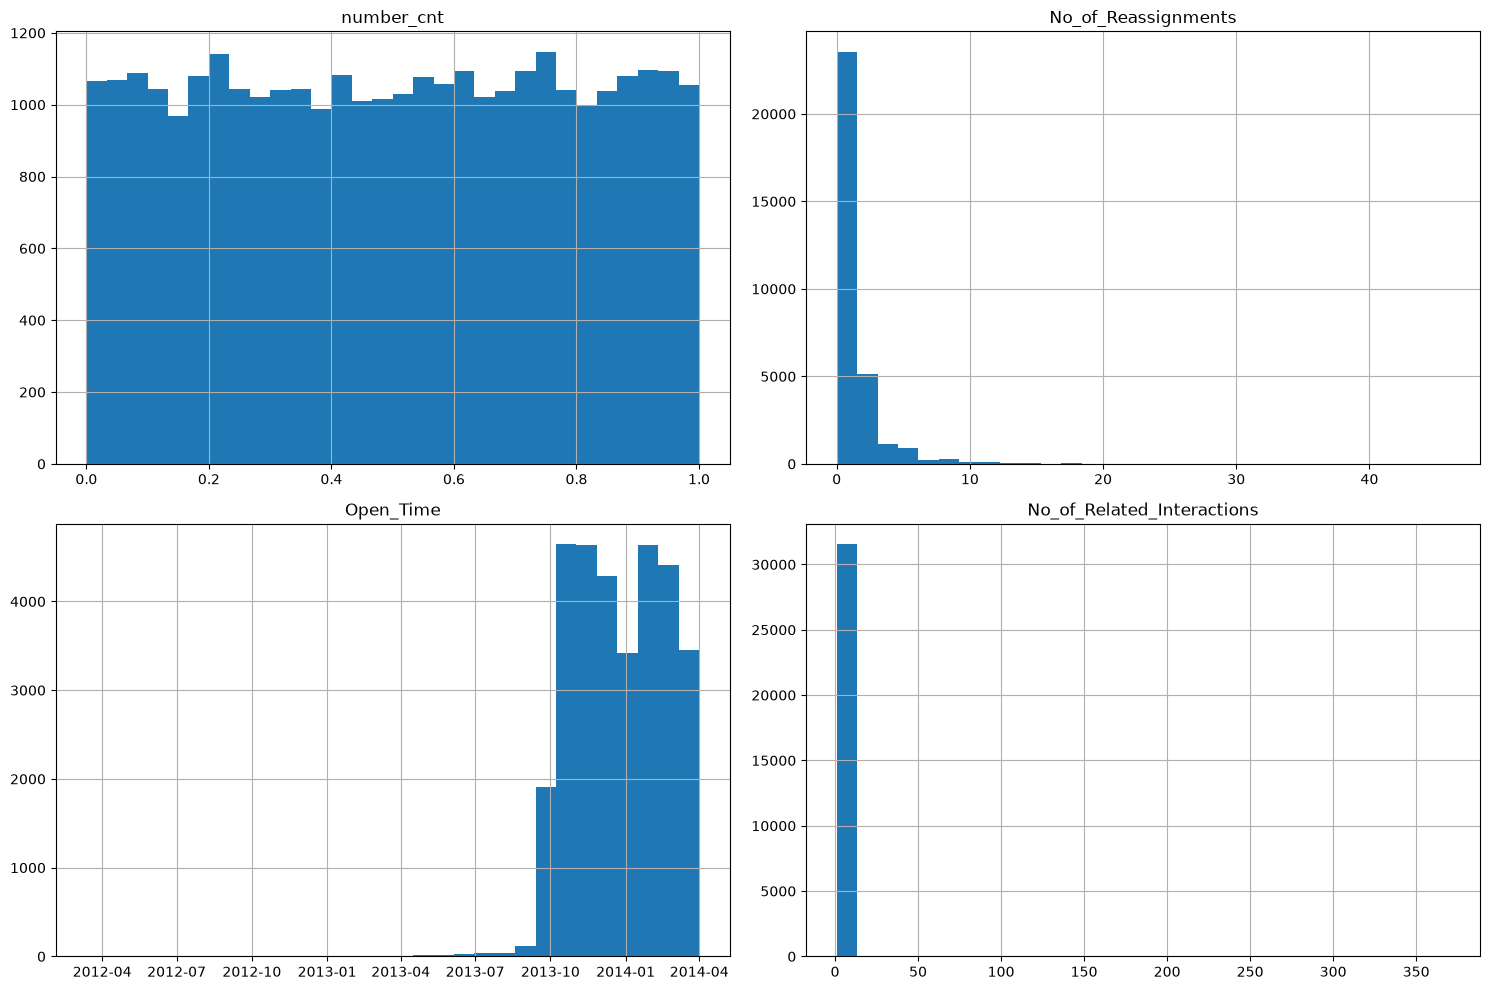

Outlier


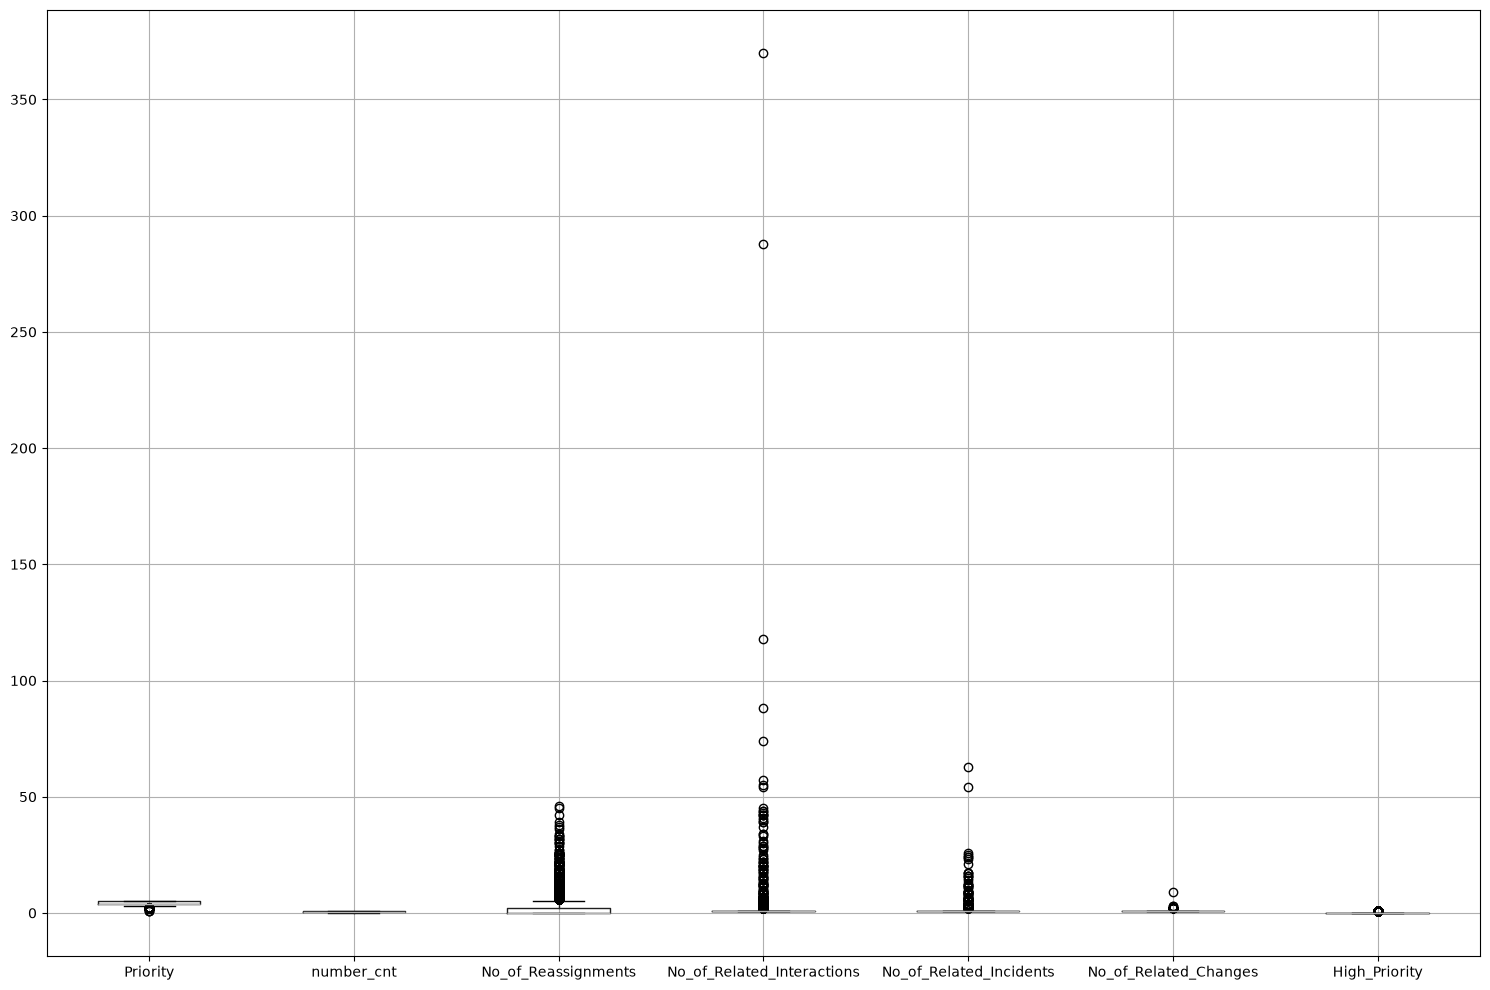

Heatmap


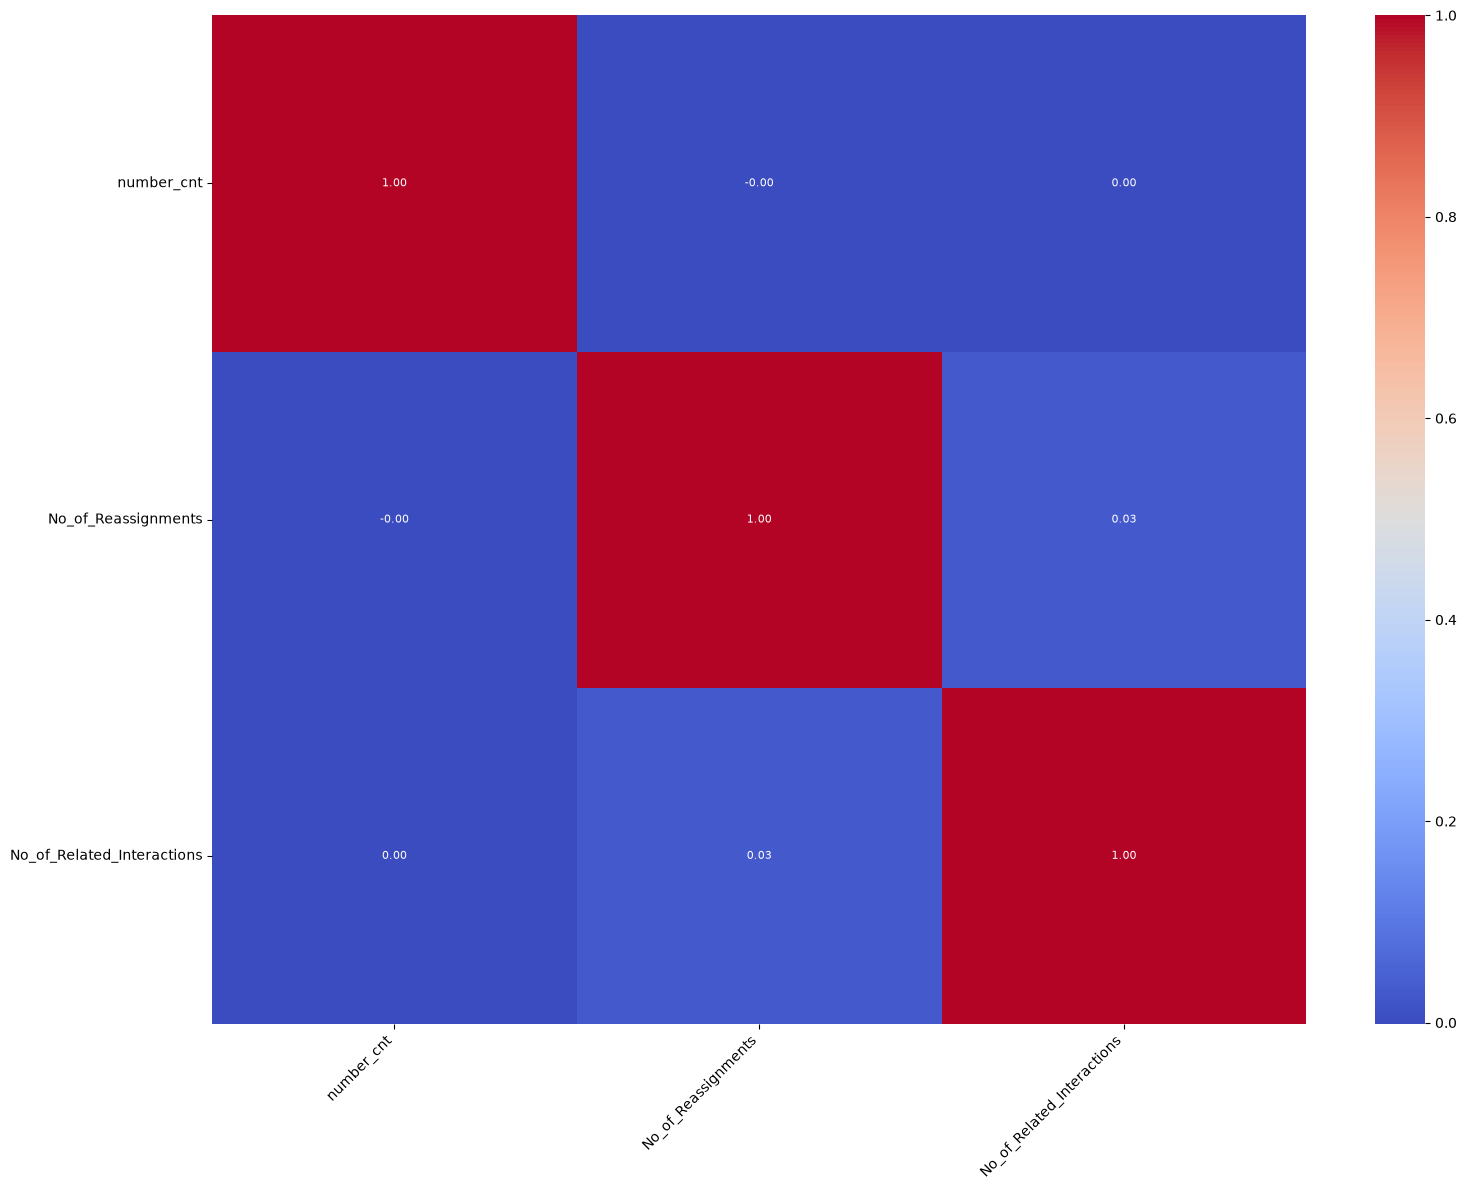

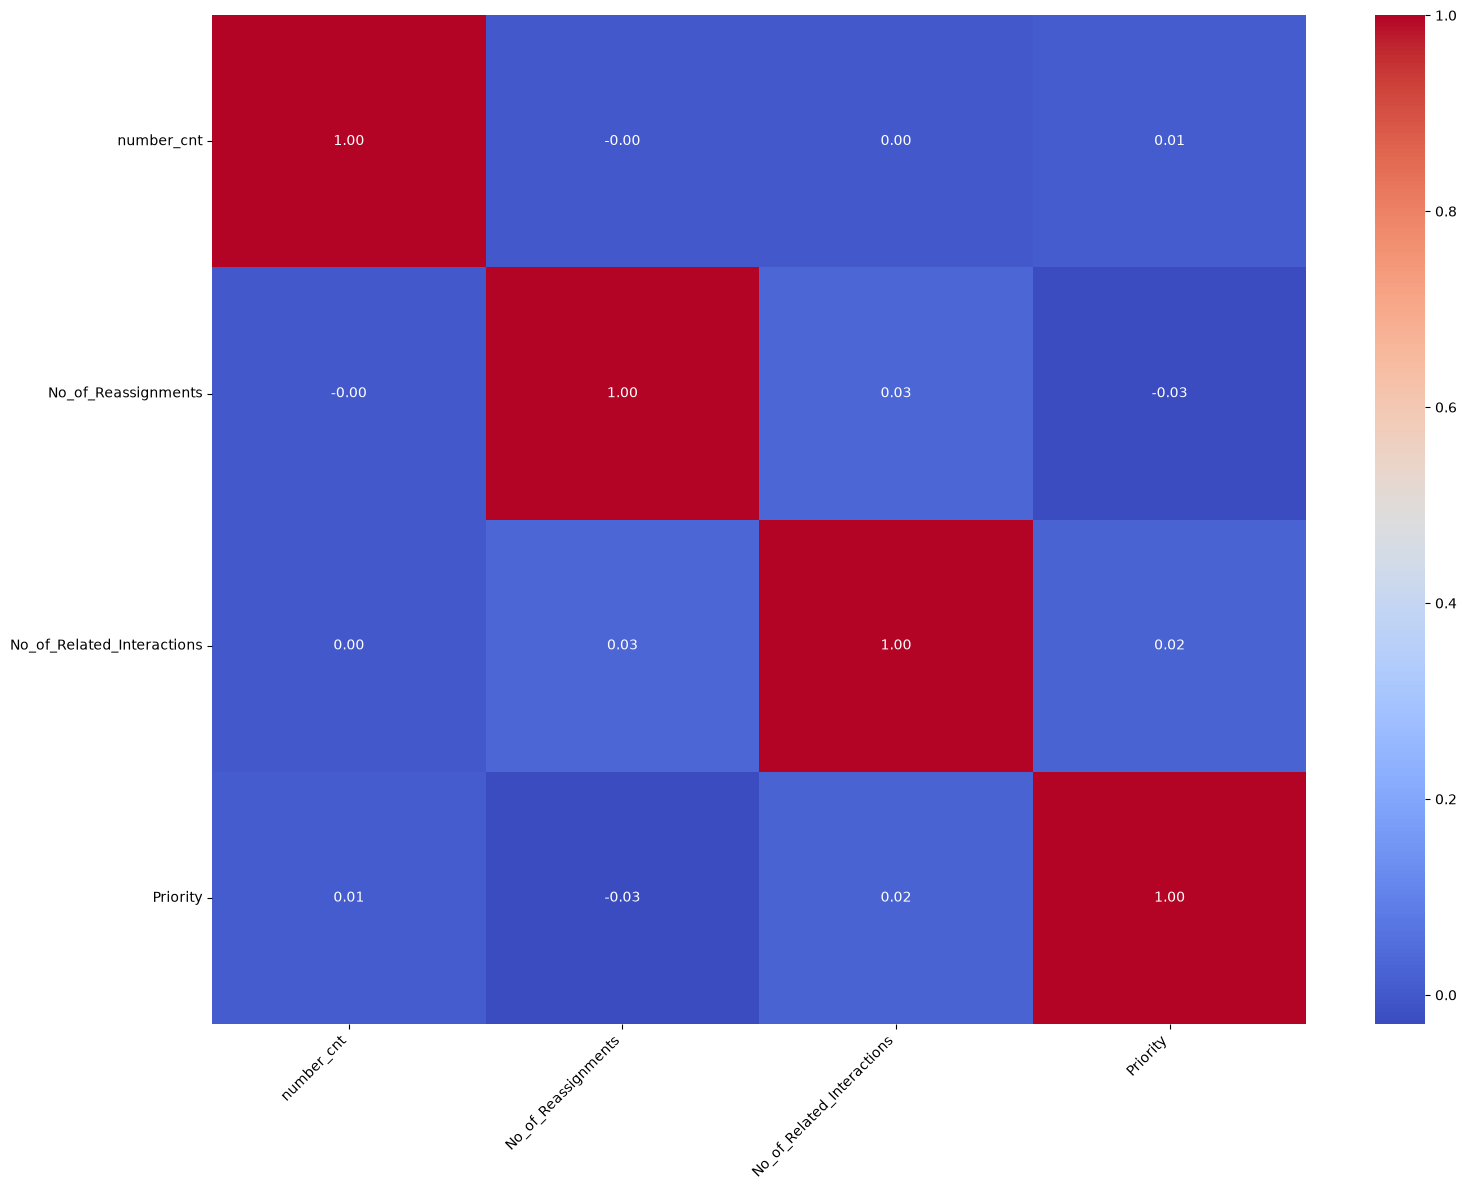

C:\Users\Welcome\AppData\Local\Temp\ipykernel_8992\3909328217.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in x_train.select_dtypes(include=['object']).columns:
C:\Users\Welcome\AppData\Local\Temp\ipykernel_8992\3909328217.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/use

                            Missing Count  Missing %
CI_Name                                 0       0.00
CI_Cat                                108       0.24
CI_Subcat                             108       0.24
WBS                                     0       0.00
Incident_ID                             0       0.00
Status                                  0       0.00
Impact                                  0       0.00
Urgency                                 0       0.00
Priority                                0       0.00
number_cnt                              0       0.00
Category                                0       0.00
KB_number                               0       0.00
Alert_Status                            0       0.00
No_of_Reassignments                     1       0.00
Open_Time                               0       0.00
Reopen_Time                         42987      95.05
Resolved_Time                        1644       3.64
Close_Time                              0     

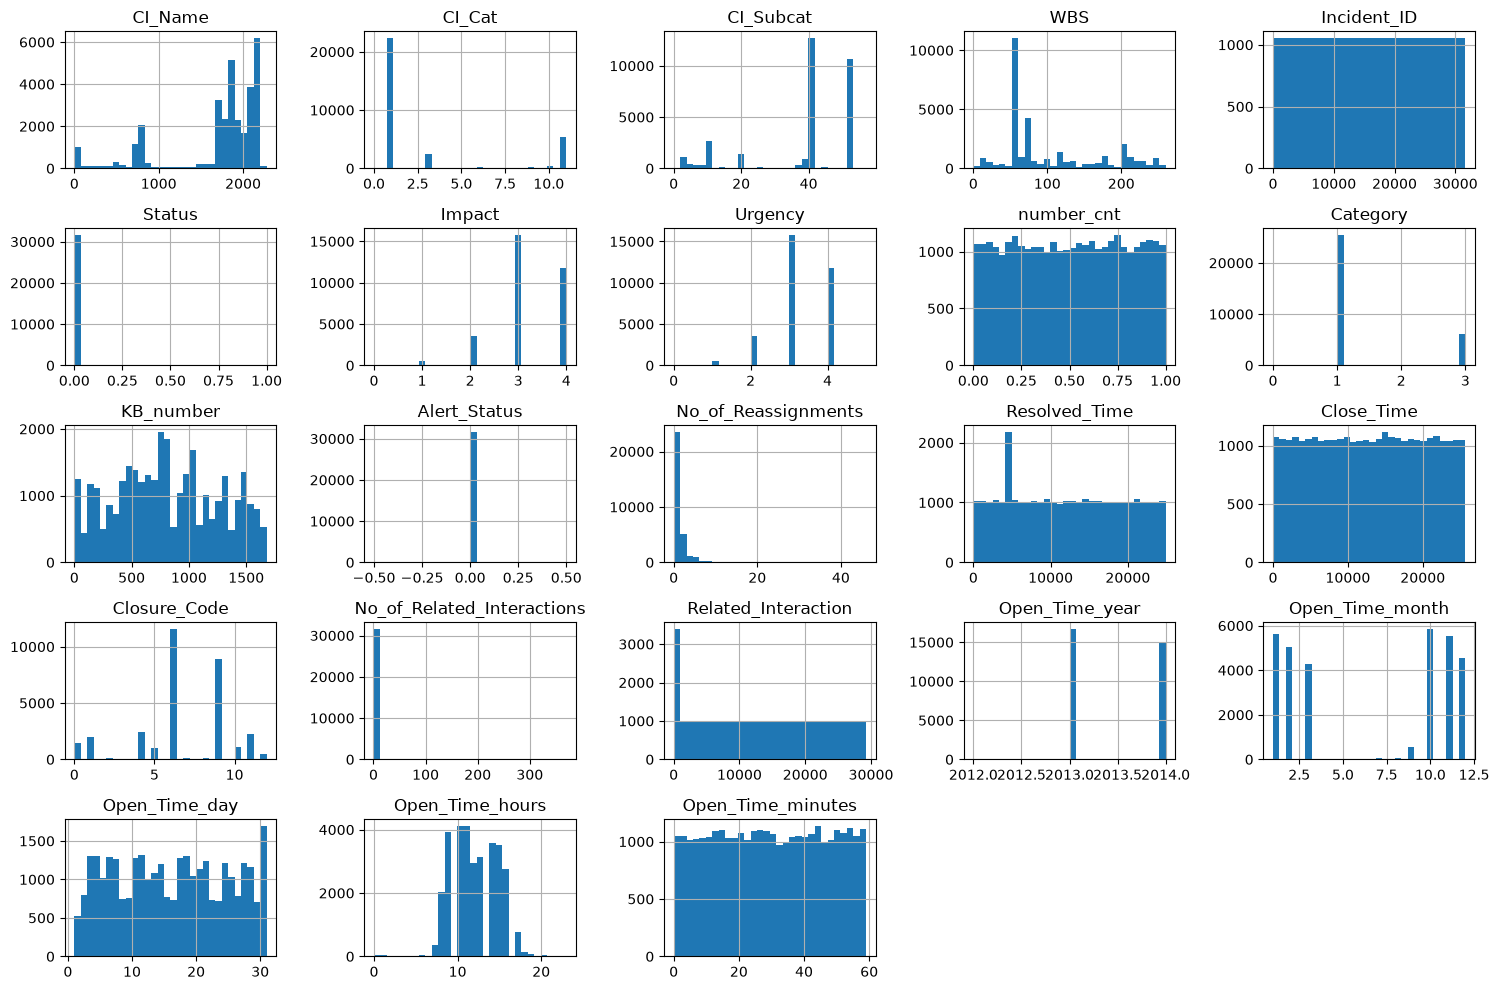

Outlier


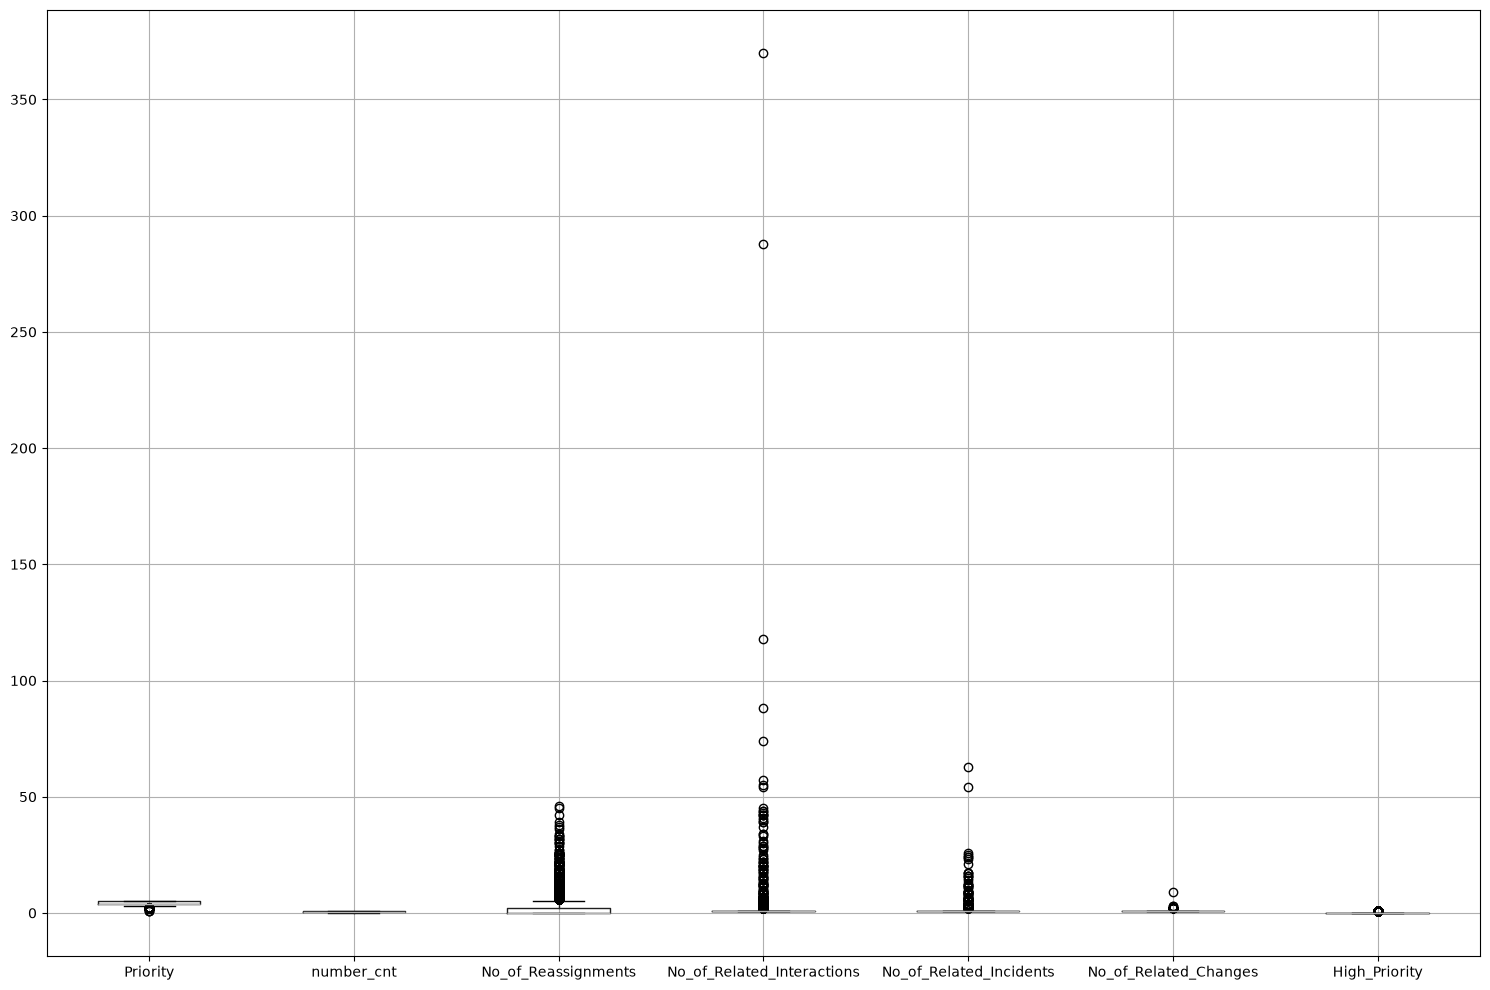

Heatmap


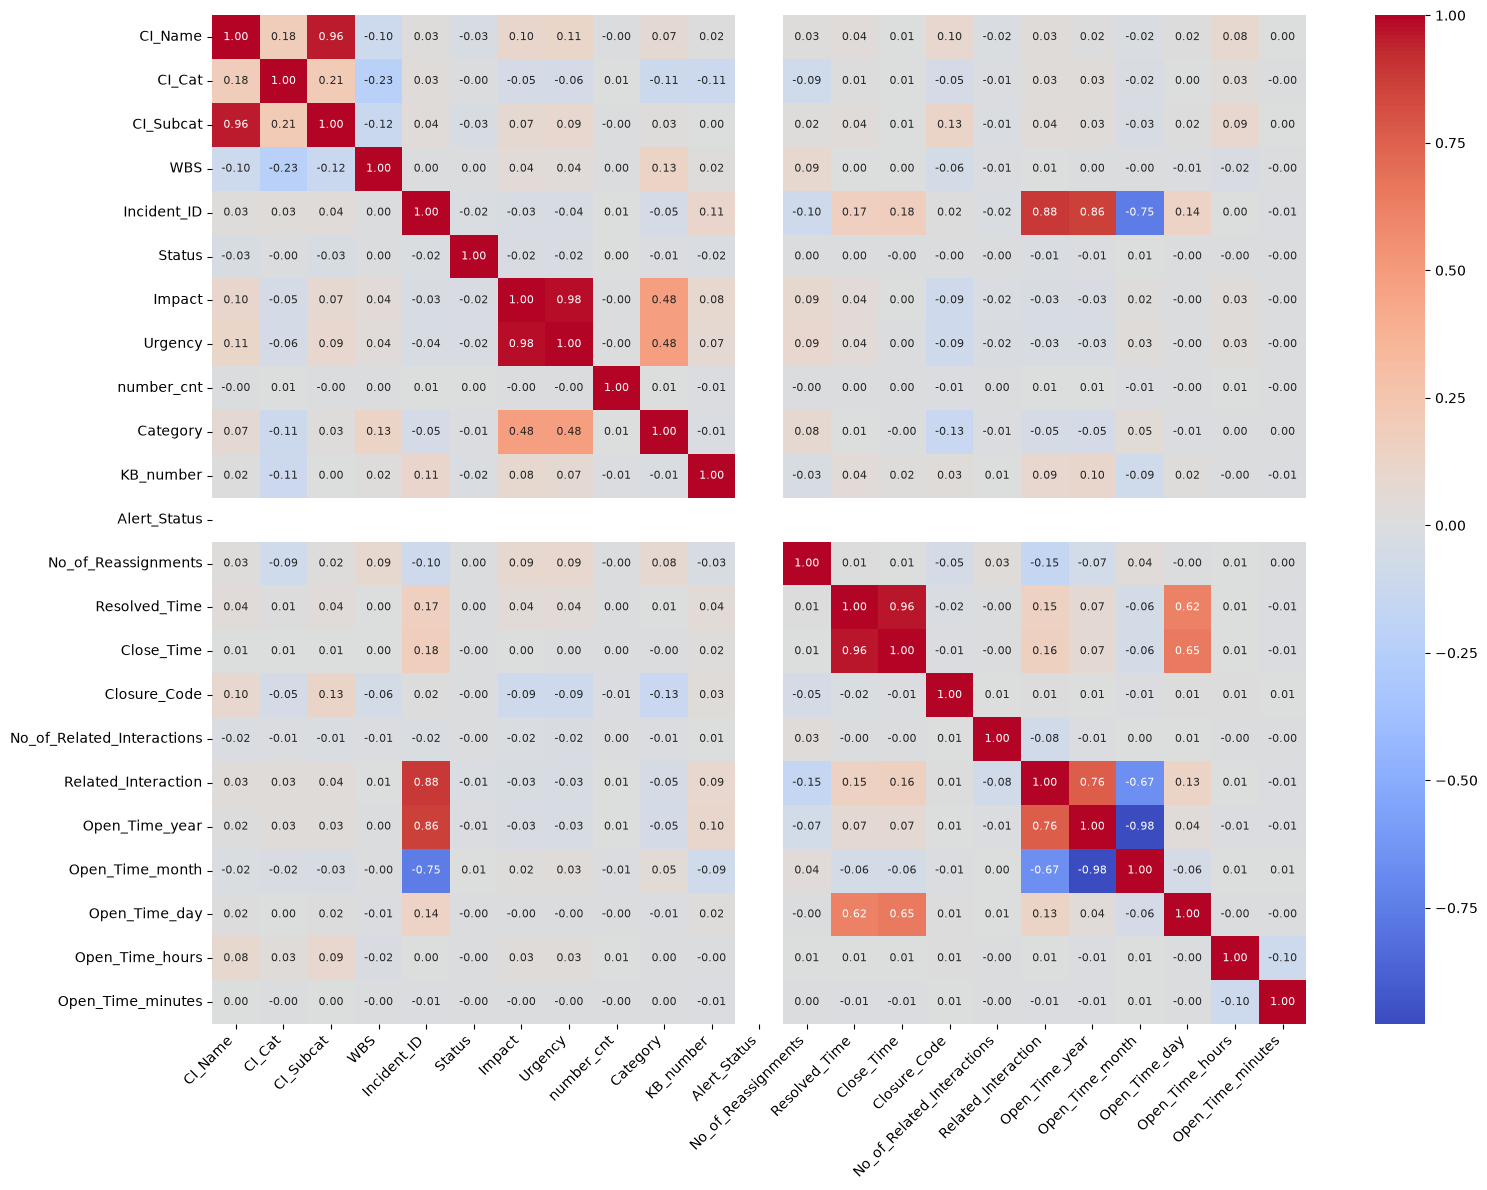

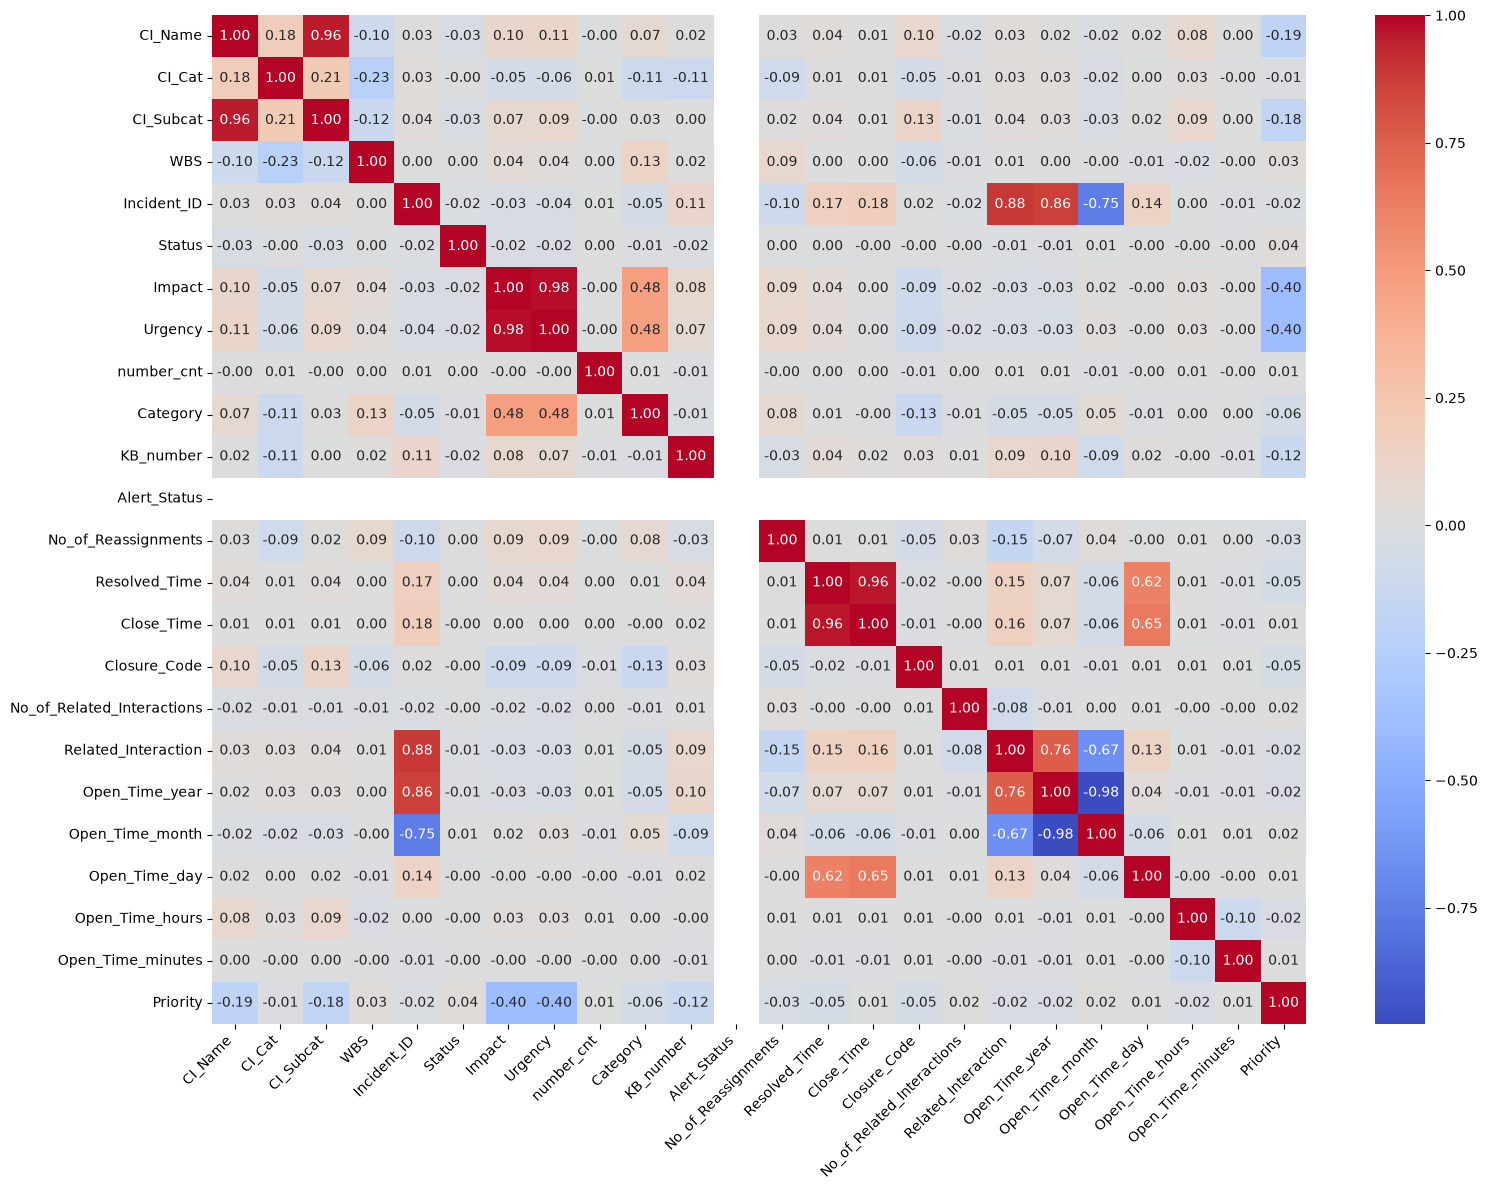

Selected Features:
Index(['CI_Subcat', 'Impact', 'Urgency'], dtype='str')
CI_Subcat    float64
Impact       float64
Urgency      float64
dtype: object
Index(['CI_Subcat', 'Impact', 'Urgency'], dtype='str')
(31658, 3)
<class 'pandas.DataFrame'>
Decision Tree Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13358
           1       1.00      1.00      1.00       210

    accuracy                           1.00     13568
   macro avg       1.00      1.00      1.00     13568
weighted avg       1.00      1.00      1.00     13568

Train Accuracy : 1.0000
Test Accuracy  : 1.0000
Gradient Boosting Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13358
           1       1.00      1.00      1.00       210

    accuracy                           1.00     13568
   macro avg       1.00      1.00      1.00     13568
weighted avg       1.00      1.00      1.00

In [29]:
model_training(x, y, times_cols)

In [96]:
df["Priority"].value_counts()

Priority
4.0    22717
5.0    16486
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64

In [6]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [89]:
pd.crosstab(
    [df["Impact"], df["Urgency"]],
    df["Priority"]
)

Priority             1.0  2.0   3.0    4.0    5.0
Impact Urgency                                   
1      1               3    0     0      0      0
2      2               0  533     0      0      0
       3               0    2     0      0      0
       2               0  156     0      0      0
       3               0    1     0      0      0
3      2               0    3     0      0      0
       3               0    0  3420      0      0
       4               0    0   111      0      0
       5               0    0     0      4      0
       1               0    2     0      0      0
       3               0    0  1657      0      0
       4               0    0    33      0      0
       5               0    0     0      4      0
4      2               0    0     2      0      0
       3               0    0    76      0      0
       4               0    0     0  15223      0
       5               0    0     0    239      0
       2               0    0     1      0      0
       3               0    0    21      0      0
       4               0    0     0   6947      0
       5               0    0     0     47      0
5      1               0    0     1      0      0
       3               0    0     0      9      0
       4               0    0     0    172      0
       5               0    0     0      0  12041
       2               0    0     1      0      0
       3               0    0     0      2      0
       4               0    0     0     70      0
       5               0    0     0      0   4444
       5 - Very Low    0    0     0      0      1

In [38]:
# 1. Get absolute counts of each class
print("--- Class Counts ---")
print(y.value_counts())

# 2. Get percentages of each class
print("\n--- Class Percentages ---")
print(y.value_counts(normalize=True) * 100)

--- Class Counts ---
Priority
4.0    22717
5.0    16486
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64

--- Class Percentages ---
Priority
4.0    50.229956
5.0    36.452483
3.0    11.769778
2.0     1.541149
1.0     0.006633
Name: proportion, dtype: float64


In [39]:
print(y.value_counts.index.tolist())

AttributeError: 'function' object has no attribute 'index'

In [47]:
imbalance_classes = []
imbalance_classes = y.value_counts().index.tolist()
imbalance_classes

[4.0, 5.0, 3.0, 2.0, 1.0]

In [51]:
len(y)

46606

In [52]:
class_pcts = y.value_counts(normalize=True) * 100

# 2. Identify classes below your threshold (e.g., 5%)
threshold = 20.0
rare_classes = class_pcts[class_pcts < threshold].index.tolist()

print("Classes to be combined:", rare_classes)

Classes to be combined: [3.0, 2.0, 1.0]


In [ ]:
y values 

In [ ]:
df["Priority_3Class"] = df["Priority"].replace({
    1.0: 1,
    2.0: 2,
    3.0: 3,
    4.0: 3,
    5.0: 3
})

In [5]:
df = pd.read_csv(r"D:/sivabalam/itsm_ml/ISTM_ML/Data/tickets.csv")

C:\Users\Welcome\AppData\Local\Temp\ipykernel_18688\3674793999.py:1: DtypeWarning: Columns (0: Urgency) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:/sivabalam/itsm_ml/ISTM_ML/Data/tickets.csv")


In [6]:
print("Original Priority Distribution:")
print(df["Priority"].value_counts().sort_index())

print("\nPercentage:")
print(
    df["Priority"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

Original Priority Distribution:
Priority
1.0        3
2.0      697
3.0     5323
4.0    22717
5.0    16486
Name: count, dtype: int64

Percentage:
Priority
1.0     0.006633
2.0     1.541149
3.0    11.769778
4.0    50.229956
5.0    36.452483
Name: proportion, dtype: float64


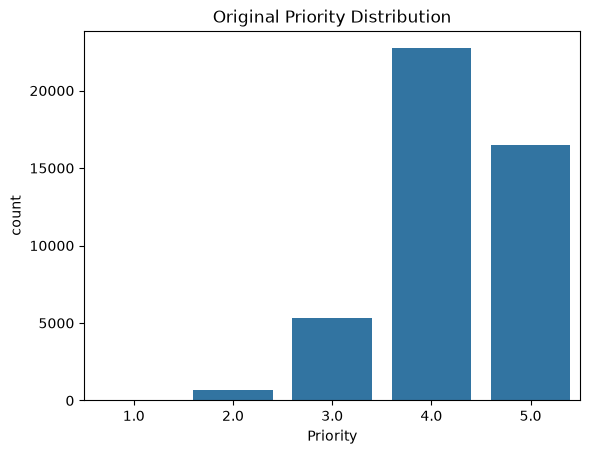

In [7]:
sns.countplot(
    data=df,
    x="Priority"
)

plt.title("Original Priority Distribution")
plt.show()

In [8]:
df["High_Priority"] = (
    df["Priority"]
    .isin([1.0, 2.0])
    .astype(int)
)

In [9]:
print(df["High_Priority"].value_counts())

print(
    df["High_Priority"]
    .value_counts(normalize=True) * 100
)

High_Priority
0    45906
1      700
Name: count, dtype: int64
High_Priority
0    98.498047
1     1.501953
Name: proportion, dtype: float64


In [10]:
def basic_eda(data):

    print("=" * 70)
    print("DATASET OVERVIEW")
    print("=" * 70)

    print("\nShape:")
    print(data.shape)

    print("\nData Types:")
    print(data.dtypes)

    print("\nMissing Values:")
    missing = pd.DataFrame({
        "Missing_Count": data.isnull().sum(),
        "Missing_Percentage": (
            data.isnull().mean() * 100
        ).round(2)
    })

    display(
        missing.sort_values(
            "Missing_Percentage",
            ascending=False
        )
    )

    print("\nDuplicate Rows:")
    print(data.duplicated().sum())

    print("\nNumerical Description:")
    display(data.describe())

    print("\nCategorical Description:")
    display(data.describe(include="object"))

In [11]:
basic_eda(df)

DATASET OVERVIEW

Shape:
(46606, 26)

Data Types:
CI_Name                           str
CI_Cat                            str
CI_Subcat                         str
WBS                               str
Incident_ID                       str
Status                            str
Impact                            str
Urgency                        object
Priority                      float64
number_cnt                    float64
Category                          str
KB_number                         str
Alert_Status                      str
No_of_Reassignments           float64
Open_Time                         str
Reopen_Time                       str
Resolved_Time                     str
Close_Time                        str
Handle_Time_hrs                   str
Closure_Code                      str
No_of_Related_Interactions    float64
Related_Interaction               str
No_of_Related_Incidents       float64
No_of_Related_Changes         float64
Related_Change                    str


,Missing_Count,Missing_Percentage
Related_Change,46046,98.80
No_of_Related_Changes,46046,98.80
No_of_Related_Incidents,45384,97.38
Reopen_Time,44322,95.10
Resolved_Time,1780,3.82
Priority,1380,2.96
Closure_Code,460,0.99
No_of_Related_Interactions,114,0.24
CI_Subcat,111,0.24
CI_Cat,111,0.24



Duplicate Rows:
0

Numerical Description:


,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,High_Priority
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000,46606.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929,0.015020
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596,0.121632
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000,0.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000,0.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000,0.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000,1.000000



Categorical Description:


C:\Users\Welcome\AppData\Local\Temp\ipykernel_18688\1814212173.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(data.describe(include="object"))


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Category,KB_number,Alert_Status,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,Related_Interaction,Related_Change
count,46606,46495,46495,46606,46606,46606,46606,46606,46606,46606,46606,46606,2284,44826,46606,46605,46146,46606,560
unique,3019,12,64,274,46606,2,6,11,4,1825,1,34636,2244,33627,34528,30638,14,43060,232
top,SUB000456,application,Server Based Application,WBS000073,IM0000004,Closed,4,4,incident,KM0001106,closed,24-03-2014 08:54,15-10-2013 09:53,10-10-2013 12:53,02-10-2013 15:20,0,Other,#MULTIVALUE,C00003013
freq,3050,32900,18811,13342,1,46597,22556,15526,37748,1106,46606,7,2,7,21,236,16470,3434,110


In [12]:
X_leakage = df.drop(
    columns=[
        "Priority",
        "High_Priority"
    ],
    errors="ignore"
)

y = df["High_Priority"]

In [13]:
X = df.drop(
    columns=[
        "Priority",
        "High_Priority",
        "Impact",
        "Urgency"
    ],
    errors="ignore"
)

y = df["High_Priority"]

In [14]:
print("Final X Shape:", X.shape)
print("Target Shape:", y.shape)

Final X Shape: (46606, 22)
Target Shape: (46606,)


In [15]:
def split_data(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [16]:
X_train, X_test, y_train, y_test = split_data(
    X,
    y
)

In [17]:
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nTraining Target:")
print(y_train.value_counts())

print("\nTesting Target:")
print(y_test.value_counts())

Train Shape: (32624, 22)
Test Shape : (13982, 22)

Training Target:
High_Priority
0    32134
1      490
Name: count, dtype: int64

Testing Target:
High_Priority
0    13772
1      210
Name: count, dtype: int64


In [18]:
def clean_data(X_train, X_test, time_cols):

    X_train = X_train.copy()
    X_test = X_test.copy()

    # --------------------------------
    # Drop columns > 50% missing
    # --------------------------------

    missing_percentage = X_train.isnull().mean()

    drop_cols = missing_percentage[
        missing_percentage > 0.50
    ].index

    print("Dropped >50% Missing Columns:")
    print(list(drop_cols))

    X_train = X_train.drop(
        columns=drop_cols,
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=drop_cols,
        errors="ignore"
    )

    # --------------------------------
    # Datetime conversion
    # --------------------------------

    for col in time_cols:

        if col in X_train.columns:

            X_train[col] = pd.to_datetime(
                X_train[col],
                format="%d-%m-%Y %H:%M",
                errors="coerce"
            )

            X_test[col] = pd.to_datetime(
                X_test[col],
                format="%d-%m-%Y %H:%M",
                errors="coerce"
            )

    # Drop Handle_Time
    X_train = X_train.drop(
        columns=["Handle_Time_hrs"],
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=["Handle_Time_hrs"],
        errors="ignore"
    )

    return X_train, X_test

In [20]:
times_cols = ["Open_Time"]

In [21]:
X_train, X_test = clean_data(
    X_train,
    X_test,
    times_cols
)

Dropped >50% Missing Columns:
['Reopen_Time', 'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']


In [22]:
def eda_after_cleaning(X_train, y_train):

    print("=" * 70)
    print("EDA AFTER CLEANING")
    print("=" * 70)

    print("\nShape:")
    print(X_train.shape)

    print("\nMissing Values:")
    print(
        X_train.isnull()
        .sum()
        .sort_values(ascending=False)
    )

    print("\nTarget Distribution:")
    print(y_train.value_counts())

    print("\nTarget Percentage:")
    print(
        y_train.value_counts(normalize=True) * 100
    )

    # Numerical columns
    numeric_cols = X_train.select_dtypes(
        include=np.number
    ).columns

    if len(numeric_cols) > 0:

        X_train[numeric_cols].hist(
            figsize=(16, 10),
            bins=30
        )

        plt.suptitle(
            "Numerical Feature Distributions"
        )

        plt.tight_layout()
        plt.show()

EDA AFTER CLEANING

Shape:
(32624, 17)

Missing Values:
Resolved_Time                 1256
Closure_Code                   328
No_of_Related_Interactions      87
CI_Subcat                       78
CI_Cat                          78
CI_Name                          0
Status                           0
WBS                              0
Incident_ID                      0
KB_number                        0
Category                         0
number_cnt                       0
Alert_Status                     0
Open_Time                        0
No_of_Reassignments              0
Close_Time                       0
Related_Interaction              0
dtype: int64

Target Distribution:
High_Priority
0    32134
1      490
Name: count, dtype: int64

Target Percentage:
High_Priority
0    98.498038
1     1.501962
Name: proportion, dtype: float64


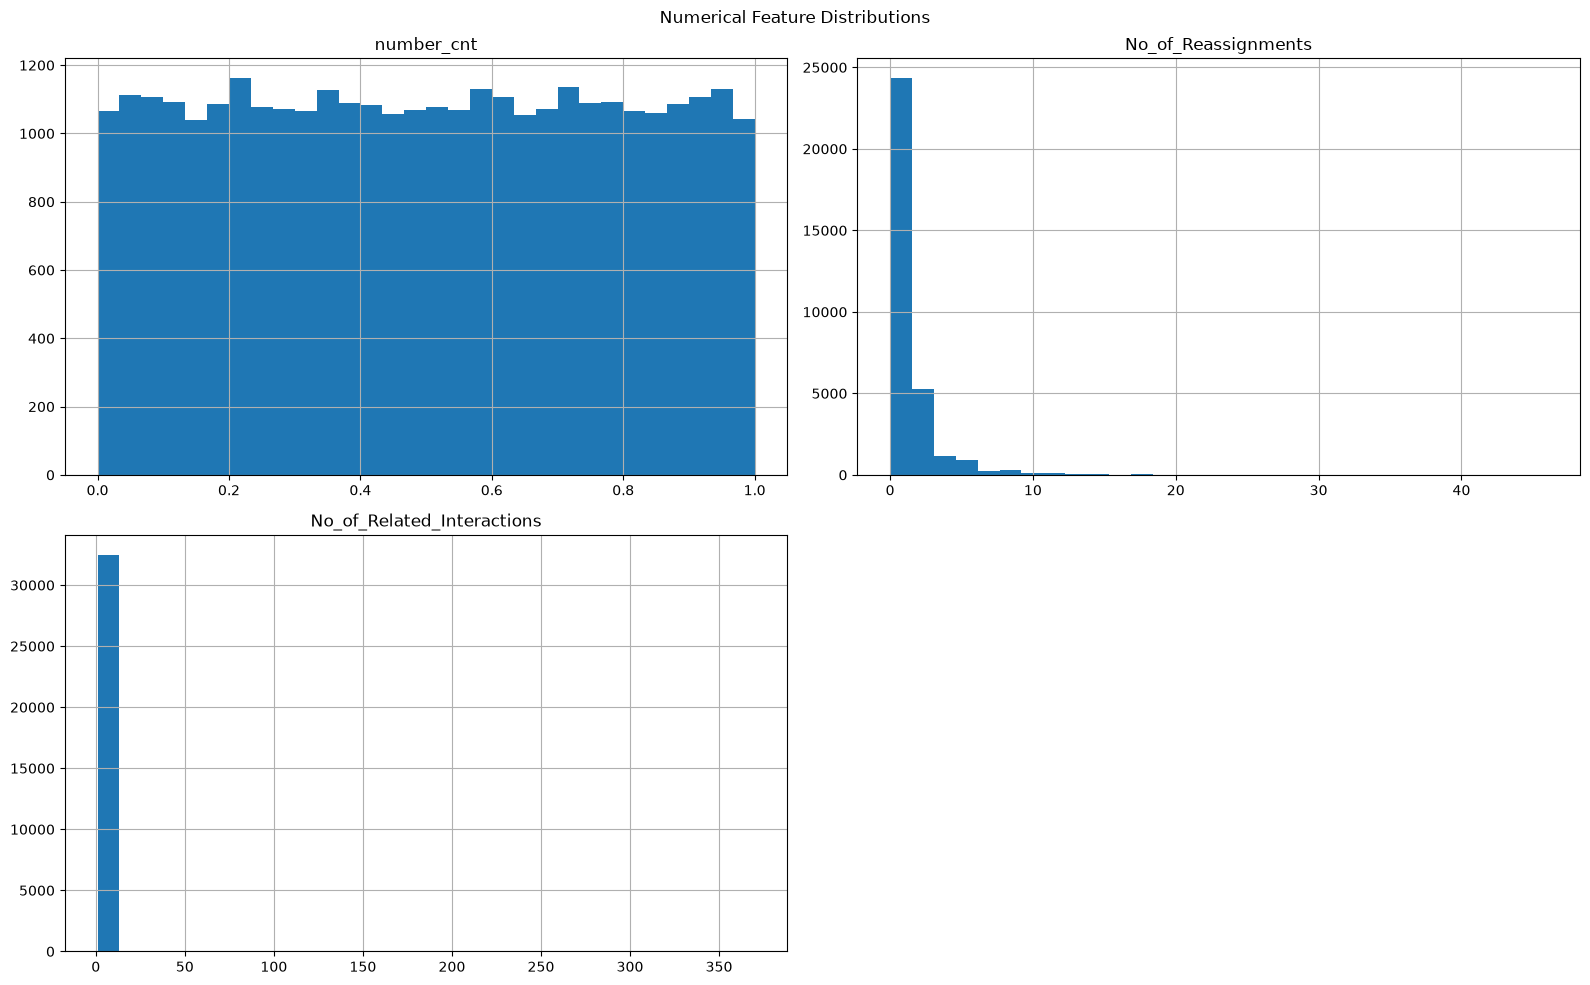

In [23]:
eda_after_cleaning(
    X_train,
    y_train
)

In [24]:
def preprocess(X_train, X_test):

    X_train = X_train.copy()
    X_test = X_test.copy()

    # -------------------------------
    # Numerical missing values
    # -------------------------------

    numeric_cols = X_train.select_dtypes(
        include="number"
    ).columns

    for col in numeric_cols:

        median = X_train[col].median()

        X_train[col] = X_train[col].fillna(
            median
        )

        X_test[col] = X_test[col].fillna(
            median
        )

    # -------------------------------
    # Categorical missing values
    # -------------------------------

    categorical_cols = X_train.select_dtypes(
        include="object"
    ).columns

    for col in categorical_cols:

        mode = X_train[col].mode()[0]

        X_train[col] = X_train[col].fillna(
            mode
        )

        X_test[col] = X_test[col].fillna(
            mode
        )

    # -------------------------------
    # Ordinal Encoding
    # -------------------------------

    categorical_cols = X_train.select_dtypes(
        include="object"
    ).columns

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train[categorical_cols] = (
        encoder.fit_transform(
            X_train[categorical_cols].astype(str)
        )
    )

    X_test[categorical_cols] = (
        encoder.transform(
            X_test[categorical_cols].astype(str)
        )
    )

    return X_train, X_test, encoder

In [25]:
X_train, X_test, encoder = preprocess(
    X_train,
    X_test
)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_18688\2090890902.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(
C:\Users\Welcome\AppData\Local\Temp\ipykernel_18688\2090890902.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migrati

In [26]:
def feature_engineering(
    X_train,
    X_test,
    time_cols
):

    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in time_cols:

        if col not in X_train.columns:
            continue

        X_train[f"{col}_year"] = (
            X_train[col].dt.year
        )

        X_train[f"{col}_month"] = (
            X_train[col].dt.month
        )

        X_train[f"{col}_day"] = (
            X_train[col].dt.day
        )

        X_train[f"{col}_hour"] = (
            X_train[col].dt.hour
        )

        X_train[f"{col}_minute"] = (
            X_train[col].dt.minute
        )

        X_test[f"{col}_year"] = (
            X_test[col].dt.year
        )

        X_test[f"{col}_month"] = (
            X_test[col].dt.month
        )

        X_test[f"{col}_day"] = (
            X_test[col].dt.day
        )

        X_test[f"{col}_hour"] = (
            X_test[col].dt.hour
        )

        X_test[f"{col}_minute"] = (
            X_test[col].dt.minute
        )

    # Drop original datetime columns
    X_train = X_train.drop(
        columns=time_cols,
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=time_cols,
        errors="ignore"
    )

    return X_train, X_test

In [27]:
X_train, X_test = feature_engineering(
    X_train,
    X_test,
    times_cols
)

In [28]:
def eda_after_fe(X_train, y_train):

    print("=" * 70)
    print("EDA AFTER FEATURE ENGINEERING")
    print("=" * 70)

    train_data = X_train.copy()

    train_data["High_Priority"] = (
        y_train.values
    )

    # --------------------------------
    # Correlation with target
    # --------------------------------

    correlation = (
        train_data
        .corr(numeric_only=True)
        ["High_Priority"]
        .sort_values(ascending=False)
    )

    print("\nCorrelation with High Priority:")
    print(correlation)

    # --------------------------------
    # Heatmap
    # --------------------------------

    plt.figure(figsize=(18, 14))

    sns.heatmap(
        train_data.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        annot_kws={"size": 7}
    )

    plt.title(
        "Correlation Heatmap After Feature Engineering"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

EDA AFTER FEATURE ENGINEERING

Correlation with High Priority:
High_Priority                 1.000000
Status                        0.049810
WBS                           0.033833
Open_Time_month               0.030596
No_of_Related_Interactions    0.023901
Open_Time_day                 0.006451
Open_Time_minute              0.006383
number_cnt                    0.005259
Close_Time                    0.004696
CI_Cat                       -0.005529
Incident_ID                  -0.023544
Open_Time_hour               -0.024156
Related_Interaction          -0.026865
No_of_Reassignments          -0.029370
Open_Time_year               -0.029855
Resolved_Time                -0.051323
Closure_Code                 -0.052057
Category                     -0.057959
KB_number                    -0.116749
CI_Subcat                    -0.185482
CI_Name                      -0.193793
Alert_Status                       NaN
Name: High_Priority, dtype: float64


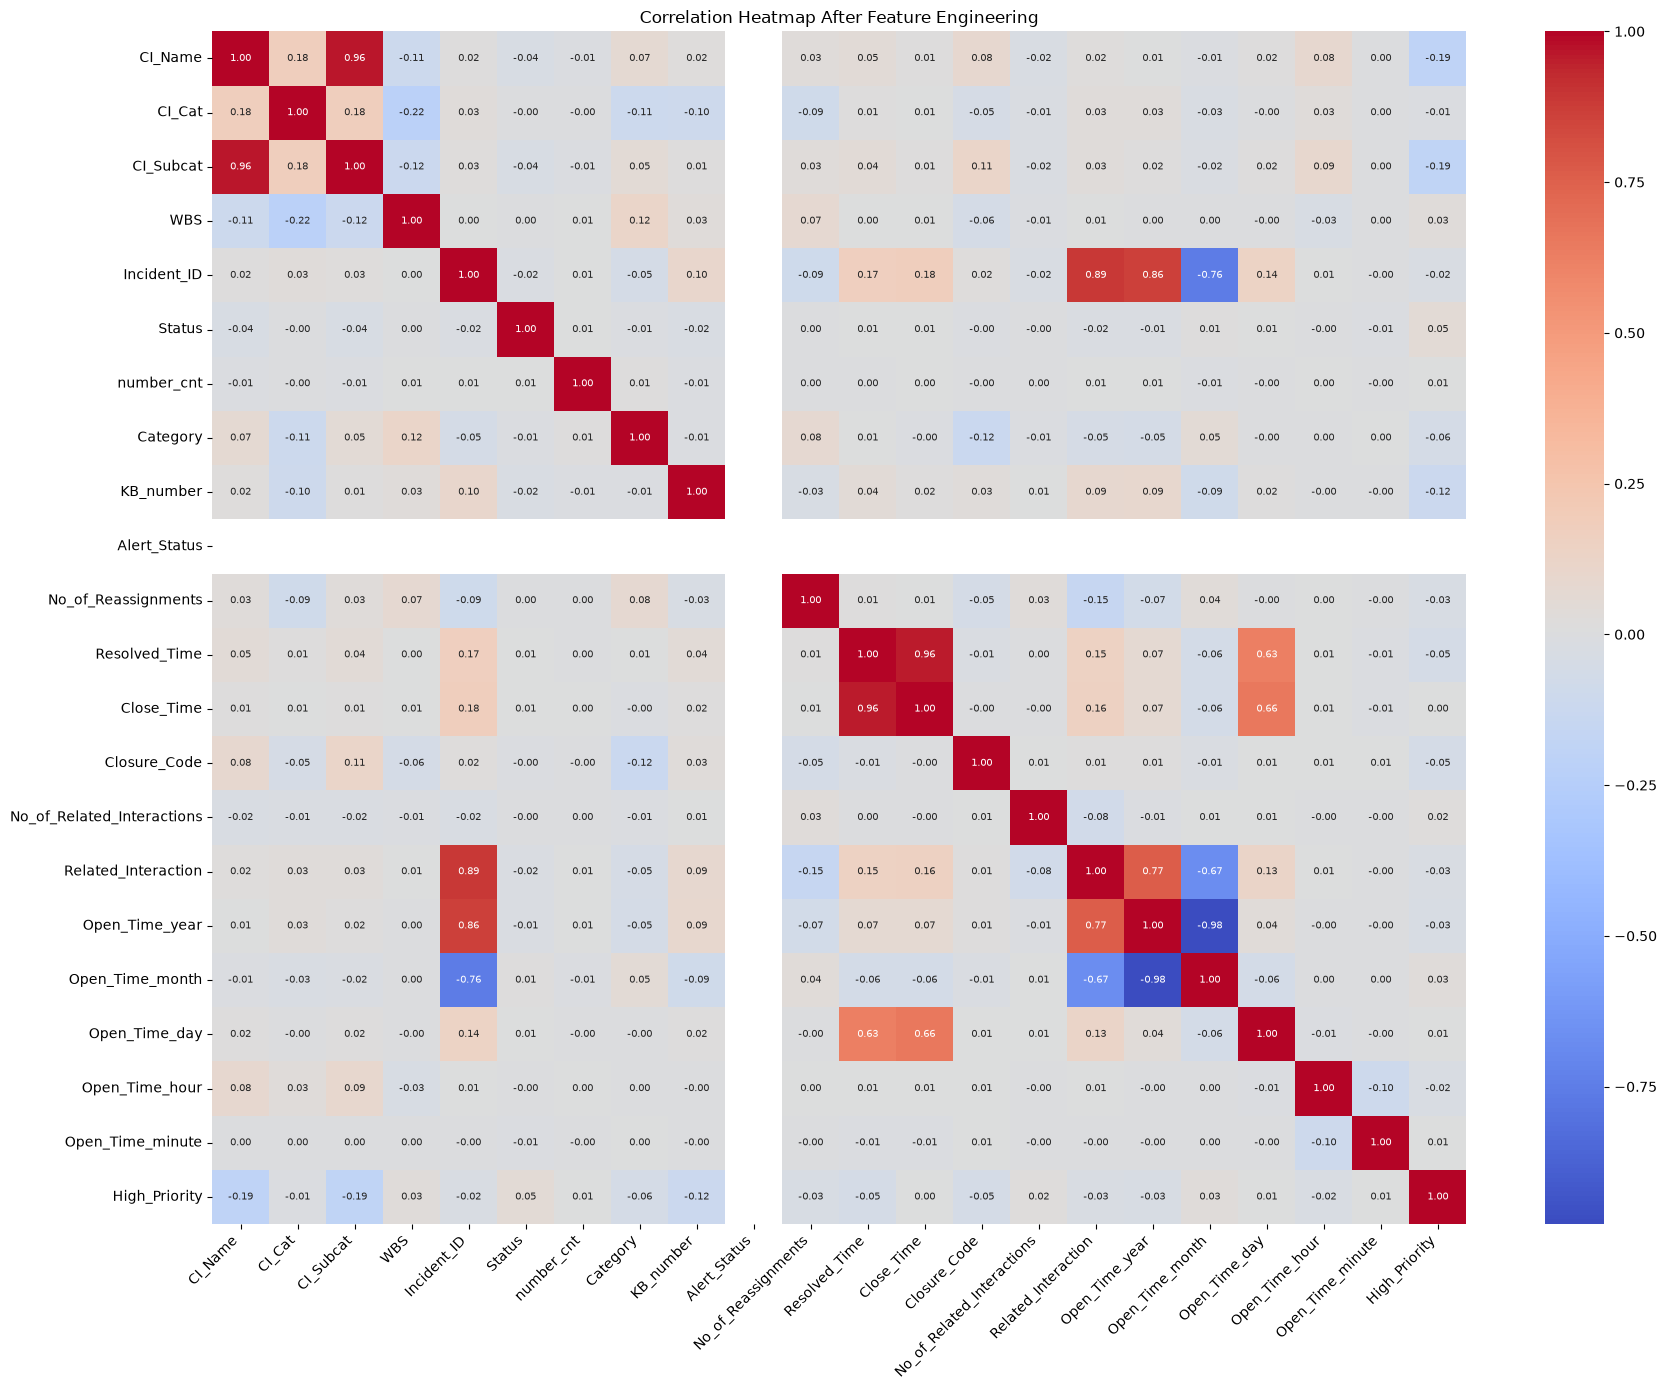

In [29]:
eda_after_fe(
    X_train,
    y_train
)

In [30]:
def feature_selection(
    X_train,
    X_test,
    y_train
):

    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(
        X_train,
        y_train
    )

    # Feature importance
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print("=" * 70)
    print("FEATURE IMPORTANCE")
    print("=" * 70)

    display(importance)

    # SelectFromModel
    selector = SelectFromModel(
        rf,
        prefit=True
    )

    selected_features = X_train.columns[
        selector.get_support()
    ]

    print("\nSelected Features:")
    print(list(selected_features))

    X_train_selected = pd.DataFrame(
        selector.transform(X_train),
        columns=selected_features,
        index=X_train.index
    )

    X_test_selected = pd.DataFrame(
        selector.transform(X_test),
        columns=selected_features,
        index=X_test.index
    )

    return (
        X_train_selected,
        X_test_selected,
        selected_features
    )

In [31]:
X_train_selected, X_test_selected, selected_features = (
    feature_selection(
        X_train,
        X_test,
        y_train
    )
)

FEATURE IMPORTANCE


,Feature,Importance
0,CI_Name,0.163672
8,KB_number,0.137043
2,CI_Subcat,0.136903
3,WBS,0.124991
1,CI_Cat,0.049836
19,Open_Time_hour,0.043047
11,Resolved_Time,0.040025
15,Related_Interaction,0.038072
6,number_cnt,0.033168
12,Close_Time,0.031835



Selected Features:
['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'KB_number']


C:\Users\Welcome\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\Welcome\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [32]:
print("Before Feature Selection:")
print(X_train.shape)

print("\nAfter Feature Selection:")
print(X_train_selected.shape)

Before Feature Selection:
(32624, 21)

After Feature Selection:
(32624, 5)


In [33]:
def check_imbalance(y_train):

    counts = y_train.value_counts()

    percentages = (
        y_train.value_counts(normalize=True)
        * 100
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print("=" * 70)
    print("CLASS IMBALANCE")
    print("=" * 70)

    display(result)

    return result

In [34]:
imbalance_report = check_imbalance(
    y_train
)

CLASS IMBALANCE


,Count,Percentage
High_Priority,,
0,32134,98.498038
1,490,1.501962


In [ ]:
def evaluate_model(
    name,
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    print(
        "Train Accuracy:",
        round(
            accuracy_score(
                y_train,
                train_pred
            ),
            4
        )
    )

    print(
        "Test Accuracy:",
        round(
            accuracy_score(
                y_test,
                test_pred
            ),
            4
        )
    )

    print(
        "Balanced Accuracy:",
        round(
            balanced_accuracy_score(
                y_test,
                test_pred
            ),
            4
        )
    )

    print(
        "High Priority Precision:",
        round(
            precision_score(
                y_test,
                test_pred,
                zero_division=0
            ),
            4
        )
    )

    print(
        "High Priority Recall:",
        round(
            recall_score(
                y_test,
                test_pred,
                zero_division=0
            ),
            4
        )
    )

    print(
        "High Priority F1:",
        round(
            f1_score(
                y_test,
                test_pred,
                zero_division=0
            ),
            4
        )
    )

    if hasattr(model, "predict_proba"):

        probability = model.predict_proba(
            X_test
        )[:, 1]

        print(
            "PR-AUC:",
            round(
                average_precision_score(
                    y_test,
                    probability
                ),
                4
            )
        )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=[
                "Non-High",
                "High"
            ],
            zero_division=0
        )
    )

    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        test_pred
    )

    print(cm)

    return model

In [36]:
!pip install xgboost imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import pandas as pd
import numpy as np

In [38]:
def get_models(class_weight=False):

    if class_weight:

        models = {

            "Decision Tree": DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ),

            "XGBoost": XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        }

    else:

        models = {

            "Decision Tree": DecisionTreeClassifier(
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                random_state=42
            ),

            "XGBoost": XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        }

    return models

In [39]:
param_grids = {

    "Decision Tree": {

        "max_depth": [
            5,
            10,
            15,
            None
        ],

        "min_samples_split": [
            2,
            5,
            10
        ],

        "min_samples_leaf": [
            1,
            2,
            5
        ]
    },


    "Random Forest": {

        "n_estimators": [
            100,
            200
        ],

        "max_depth": [
            10,
            20,
            None
        ],

        "min_samples_split": [
            2,
            5
        ],

        "min_samples_leaf": [
            1,
            2
        ]
    },


    "XGBoost": {

        "n_estimators": [
            100,
            200
        ],

        "max_depth": [
            3,
            5,
            7
        ],

        "learning_rate": [
            0.05,
            0.1
        ],

        "subsample": [
            0.8,
            1.0
        ]
    }
}

In [41]:
all_results = []
best_models = {}


def train_and_tune(
    experiment_name,
    models,
    X_train_exp,
    y_train_exp,
    X_test,
    y_test
):

    print("\n")
    print("=" * 80)
    print(f"EXPERIMENT: {experiment_name}")
    print("=" * 80)

    for model_name, model in models.items():

        print("\n" + "-" * 70)
        print(f"MODEL: {model_name}")
        print("-" * 70)

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],

            # Important for Problem 1
            scoring="recall",

            cv=5,
            n_jobs=-1,
            verbose=0
        )

        grid.fit(
            X_train_exp,
            y_train_exp
        )

        best_model = grid.best_estimator_

        print("Best Parameters:")
        print(grid.best_params_)

        print(
            "Best CV Recall:",
            round(grid.best_score_, 4)
        )

        # ---------------------------------
        # Predictions
        # ---------------------------------

        train_pred = best_model.predict(
            X_train_exp
        )

        test_pred = best_model.predict(
            X_test
        )

        # ---------------------------------
        # Probabilities
        # ---------------------------------

        test_probability = (
            best_model.predict_proba(
                X_test
            )[:, 1]
        )

        # ---------------------------------
        # Metrics
        # ---------------------------------

        train_accuracy = accuracy_score(
            y_train_exp,
            train_pred
        )

        test_accuracy = accuracy_score(
            y_test,
            test_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_test,
            test_pred
        )

        precision = precision_score(
            y_test,
            test_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            test_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            test_pred,
            zero_division=0
        )

        pr_auc = average_precision_score(
            y_test,
            test_probability
        )

        # ---------------------------------
        # Print
        # ---------------------------------

        print("\nTrain Accuracy:",
              round(train_accuracy, 4))

        print("Test Accuracy:",
              round(test_accuracy, 4))

        print("Balanced Accuracy:",
              round(balanced_acc, 4))

        print("High Priority Precision:",
              round(precision, 4))

        print("High Priority Recall:",
              round(recall, 4))

        print("High Priority F1:",
              round(f1, 4))

        print("PR-AUC:",
              round(pr_auc, 4))

        print("\nClassification Report:")

        print(
            classification_report(
                y_test,
                test_pred,
                target_names=[
                    "Non-High",
                    "High"
                ],
                zero_division=0
            )
        )

        print("Confusion Matrix:")

        print(
            confusion_matrix(
                y_test,
                test_pred
            )
        )

        # ---------------------------------
        # Save results
        # ---------------------------------

        all_results.append({

            "Experiment": experiment_name,

            "Model": model_name,

            "Train Accuracy": train_accuracy,

            "Test Accuracy": test_accuracy,

            "Balanced Accuracy": balanced_acc,

            "Precision High": precision,

            "Recall High": recall,

            "F1 High": f1,

            "PR-AUC": pr_auc,

            "Best Parameters":
                grid.best_params_
        })

        best_models[
            f"{experiment_name}_{model_name}"
        ] = best_model

In [42]:
print("=" * 70)
print("EXPERIMENT A - BASELINE")
print("=" * 70)

print("Training Distribution:")
print(y_train.value_counts())

EXPERIMENT A - BASELINE
Training Distribution:
High_Priority
0    32134
1      490
Name: count, dtype: int64


In [43]:
models_A = get_models(
    class_weight=False
)

In [44]:
train_and_tune(
    experiment_name="A - Baseline",

    models=models_A,

    X_train_exp=X_train_selected,
    y_train_exp=y_train,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: A - Baseline

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Recall: 0.5857

Train Accuracy: 0.9887
Test Accuracy: 0.9878
Balanced Accuracy: 0.6937
High Priority Precision: 0.6613
High Priority Recall: 0.3905
High Priority F1: 0.491
PR-AUC: 0.4047

Classification Report:
              precision    recall  f1-score   support

    Non-High       0.99      1.00      0.99     13772
        High       0.66      0.39      0.49       210

    accuracy                           0.99     13982
   macro avg       0.83      0.69      0.74     13982
weighted avg       0.99      0.99      0.99     13982

Confusion Matrix:
[[13730    42]
 [  128    82]]

----------------------------------------------------------------------
MODEL: Random Forest
----------------------------------------

In [45]:
models_B = {

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    )
}

In [46]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = (
    negative / positive
)

print(
    "XGBoost scale_pos_weight:",
    scale_pos_weight
)

XGBoost scale_pos_weight: 65.57959183673469


In [47]:
models_B["XGBoost"] = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [48]:
train_and_tune(
    experiment_name="B - Class Weight",

    models=models_B,

    X_train_exp=X_train_selected,
    y_train_exp=y_train,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: B - Class Weight

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Recall: 0.8122

Train Accuracy: 0.9265
Test Accuracy: 0.9229
Balanced Accuracy: 0.853
High Priority Precision: 0.1371
High Priority Recall: 0.781
High Priority F1: 0.2333
PR-AUC: 0.4036

Classification Report:
              precision    recall  f1-score   support

    Non-High       1.00      0.93      0.96     13772
        High       0.14      0.78      0.23       210

    accuracy                           0.92     13982
   macro avg       0.57      0.85      0.60     13982
weighted avg       0.98      0.92      0.95     13982

Confusion Matrix:
[[12740  1032]
 [   46   164]]

----------------------------------------------------------------------
MODEL: Random Forest
------------------------------------

In [50]:
print("=" * 70)
print("EXPERIMENT C - SMOTE")
print("=" * 70)

print("Before SMOTE:")

print(
    y_train.value_counts()
)

EXPERIMENT C - SMOTE
Before SMOTE:
High_Priority
0    32134
1      490
Name: count, dtype: int64


In [51]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_selected,
        y_train
    )
)

In [52]:
print("\nAfter SMOTE:")

print(
    y_train_smote.value_counts()
)


After SMOTE:
High_Priority
0    32134
1    32134
Name: count, dtype: int64


In [54]:
models_C = get_models(
    class_weight=False
)

In [55]:
train_and_tune(
    experiment_name="C - SMOTE",

    models=models_C,

    X_train_exp=X_train_smote,
    y_train_exp=y_train_smote,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: C - SMOTE

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Recall: 0.9834

Train Accuracy: 0.9794
Test Accuracy: 0.9562
Balanced Accuracy: 0.7011
High Priority Precision: 0.157
High Priority Recall: 0.4381
High Priority F1: 0.2312
PR-AUC: 0.177

Classification Report:
              precision    recall  f1-score   support

    Non-High       0.99      0.96      0.98     13772
        High       0.16      0.44      0.23       210

    accuracy                           0.96     13982
   macro avg       0.57      0.70      0.60     13982
weighted avg       0.98      0.96      0.97     13982

Confusion Matrix:
[[13278   494]
 [  118    92]]

----------------------------------------------------------------------
MODEL: Random Forest
-----------------------------------------